**Objective -**     

The focus is on predicting the quality of wine based on it's chemical characteristics, offering a real world application of machine learning in the context of viticulture. The project also aims to analyze the dataset, identify patterns, visualize the data and compare different machine learning models. 

**Understanding The Dataset -**     

The dataset contains the chemical properties of different wine samples. Each row represents one wine sample and each column represents a specific chemical characteristic. The goal is to predict the wine's quality using machine learning.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [2]:
# Load Dataset

df = pd.read_csv("D:/Downloads/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


**Observation -**  

Each `row` represents one `wine sample`, where as, each `column` represents one `property of that wine`.  
The column, `quality`, is the value we want our machine learning model to predict.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


**Observation -**  

We can see all the detailed information about the dataset, including number of rows and columns, non-null values and whether all variables have appropriate data types or not.

In [4]:
# Check Missing Values

df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

**Observation -**

No missing values were found.

In [5]:
# Check Duplicate Values

df.duplicated().sum()

np.int64(0)

**Observation -**  

No duplicate values were found.

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


**Observation -**

We can see a statistical summary of all numerical columns in the dataset.

In [7]:
df.mean(numeric_only = True)    # avg value

fixed acidity             8.311111
volatile acidity          0.531339
citric acid               0.268364
residual sugar            2.532152
chlorides                 0.086933
free sulfur dioxide      15.615486
total sulfur dioxide     45.914698
density                   0.996730
pH                        3.311015
sulphates                 0.657708
alcohol                  10.442111
quality                   5.657043
Id                      804.969379
dtype: float64

In [8]:
df.median(numeric_only = True)    # middle value

fixed acidity             7.90000
volatile acidity          0.52000
citric acid               0.25000
residual sugar            2.20000
chlorides                 0.07900
free sulfur dioxide      13.00000
total sulfur dioxide     37.00000
density                   0.99668
pH                        3.31000
sulphates                 0.62000
alcohol                  10.20000
quality                   6.00000
Id                      794.00000
dtype: float64

In [9]:
df.mode().iloc[0]    # most frequently occurring value

fixed acidity            7.2000
volatile acidity         0.5000
citric acid              0.0000
residual sugar           2.0000
chlorides                0.0800
free sulfur dioxide      6.0000
total sulfur dioxide    28.0000
density                  0.9976
pH                       3.3000
sulphates                0.6000
alcohol                  9.5000
quality                  5.0000
Id                       0.0000
Name: 0, dtype: float64

In [10]:
df.std(numeric_only = True)     # spread of the values around the average

fixed acidity             1.747595
volatile acidity          0.179633
citric acid               0.196686
residual sugar            1.355917
chlorides                 0.047267
free sulfur dioxide      10.250486
total sulfur dioxide     32.782130
density                   0.001925
pH                        0.156664
sulphates                 0.170399
alcohol                   1.082196
quality                   0.805824
Id                      463.997116
dtype: float64

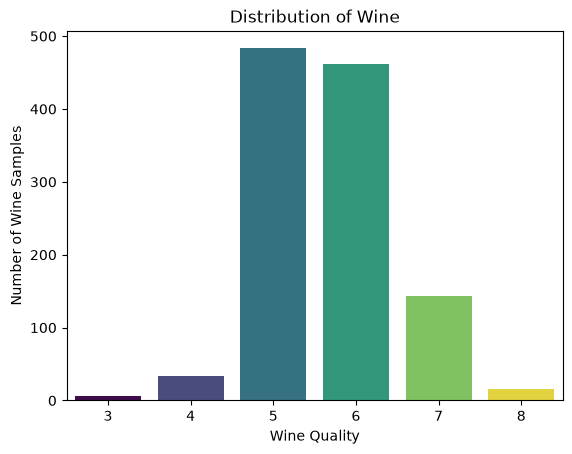

In [37]:
sns.countplot(x = "quality", data = df , hue = "quality", palette = "viridis", legend = False)
plt.title("Distribution of Wine")

plt.xlabel("Wine Quality")
plt.ylabel("Number of Wine Samples")
plt.show()

**Observation -**

The graph shows the distribution of wine quality ratings. `X-axis` represents the `Wine Quality`, where as, `Y-axis` represent the `Number of Wine Samples`.  
Most wine samples have quality of 5 and 6 showcasing that these are the most common quality levels, where as, few wines have quality of 3, 4 or 8.

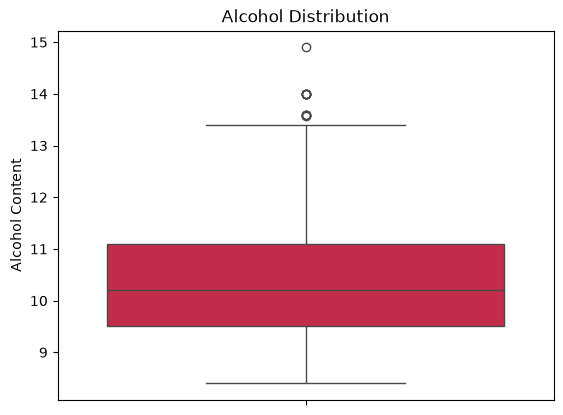

In [39]:
sns.boxplot(y = "alcohol", data = df, color = "crimson", fliersize = 6)
plt.title("Alcohol Distribution")

plt.ylabel("Alcohol Content")
plt.show()

**Observation -**  

The graph shows the distribution of alcohol content in the wine dataset.`X-axis` represents the `dataset`, whereas, `Y-axis` represents the `alcohol content` in the wine.  
The median alcohol content is approx 10%. Most wine samples have alcohol content between 9.5% to 11%.  
The whiskers show the normal range of alcohol values. There are some outliers as well, showing that some wines have unusually high alcohol content.

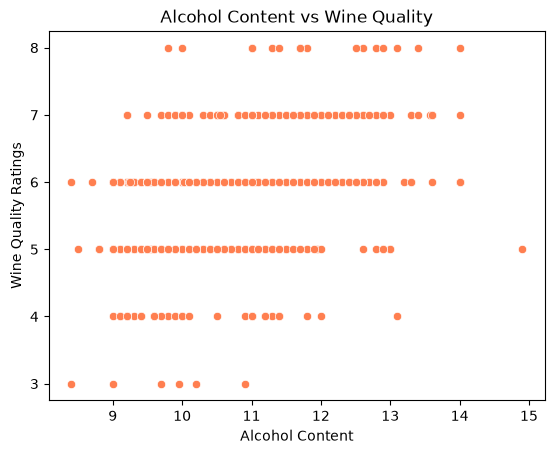

In [40]:
sns.scatterplot(x = "alcohol", y = "quality", data = df, color = "coral")
plt.title("Alcohol Content vs Wine Quality")

plt.xlabel("Alcohol Content")
plt.ylabel("Wine Quality Ratings")
plt.show()

**Observation -**

The graph shows the relationship between alcohol content and wine quality. `X-axis` represents the `alcohol content` of wine samples, whereas, `Y-axis` represents the `wine quality ratings`.  
Most wine samples have alcohol content between 9% to 13%.  
The quality ratings 5, 6 and 7 have the highest number of alcohol content.

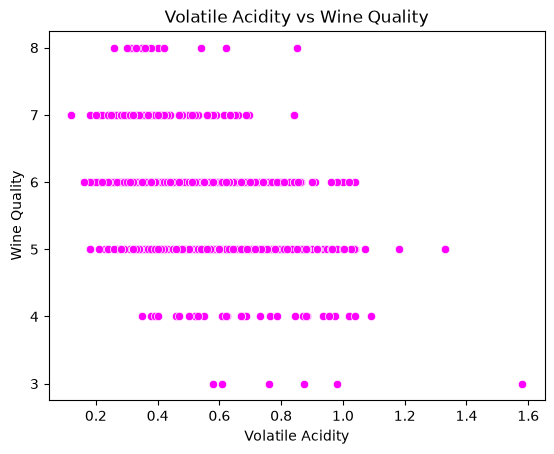

In [41]:
sns.scatterplot(x = "volatile acidity", y = "quality", data = df, color = "magenta")
plt.title("Volatile Acidity vs Wine Quality")

plt.xlabel("Volatile Acidity")
plt.ylabel("Wine Quality")
plt.show()

**Observation -**

The graph shows the relationship between `volatile acidity` and `wine quality`.`X-axis` represents the `volatile acidity` of the wine samples, where as, `Y-axis` represents the `wine quality ratings`.    
Most wine samples have volatile acidity between 0.2 and 0.8.   
Quality ratings 5 and 6 have the highest number of wine samples.  
Wines with lower volatile acidity generally tend to have higher quality ratings and vice versa.

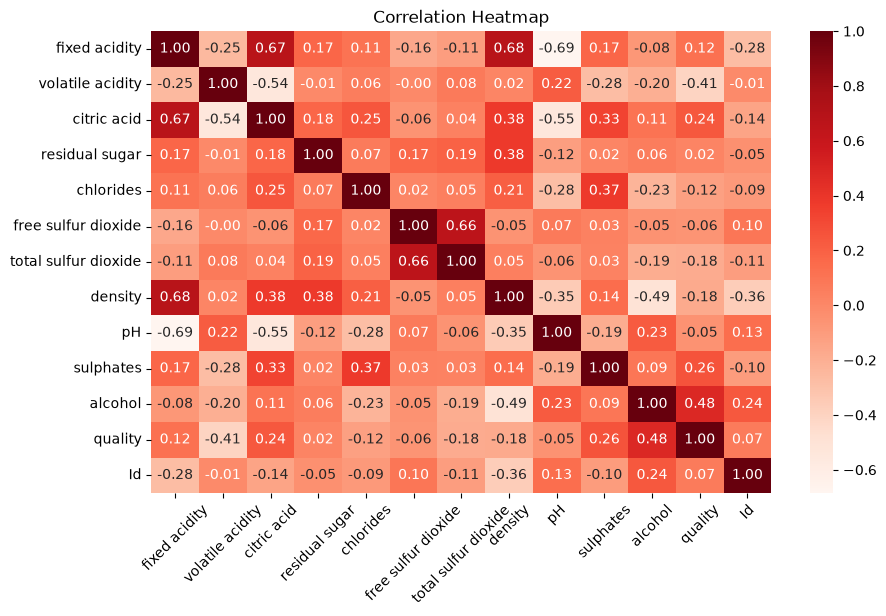

In [15]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(), annot = True, cmap = "Reds", fmt = ".2f")

plt.title("Correlation Heatmap")
plt.xticks(rotation = 45)
plt.show()

**Observation -**  

The `correlation heatmap` shows the relationship between all numerical features in the dataset.`X-axis` represents the the `wine chemical characteristics`, where as, `Y-axis` represents the same `wine features` that are used to compare their correlation with each other.

Correlation values range from -1 to +1. The diagonal values are 1.00 as every feature is perfectly correlated with itself.  
Positive values mean that two features increase together, while negative values mean that one feature increases as the other decreases.

In [16]:
df = df.drop("Id", axis = 1)

**Observation -**  

The `Id column` does not tell anything about the wine's quality, so it's dropped.

In [17]:
x = df.drop("quality", axis = 1)
y = df["quality"]

**Observation -**  

The dataset was divided into `features(x)` and the `target(y)`.   
Features contain all the chemical properties of the wine, whereas, the target variable contains the wine quality.

In [18]:
# Splitting the Dataset

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Observation -**

The dataset was divided into training and testing sets.  
`80%` of the data will be used to train the machine learning models, while the remaining `20%` will be used for testing.

In [19]:
# Feature Scaling

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

**Observation -**  

We have standardized the numerical features of the dataset, so that they have a similar scale. This helps machine learning models to perform more effeciently.

In [20]:
# Training the SGD Classifier Model

sgd_model = SGDClassifier(random_state = 42)
sgd_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [21]:
# Prediction

sgd_pred = sgd_model.predict(x_test)

In [22]:
# Accuracy Analysis

sgd_accuracy = accuracy_score(y_test, sgd_pred)
print(sgd_accuracy)

0.5021834061135371


**Observation -**  

The `SGD Classifier` model achieved an accuracy of approx `50%`.

In [23]:
# Classification Report

print(classification_report(y_test, sgd_pred, zero_division = 0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.57      0.80      0.67        96
           6       0.53      0.24      0.33        99
           7       0.30      0.54      0.39        26
           8       0.00      0.00      0.00         2

    accuracy                           0.50       229
   macro avg       0.24      0.26      0.23       229
weighted avg       0.51      0.50      0.47       229



**Observation -**  

The model performed best for quality 5, with an F1 score of 0.67.  
The model gave moderate performance for quality 6 and 7, but many samples were misclassified.  
The model failed to predict quality 3, 4, and 8 correctly, resulting in precision, recall, and F1-score of 0. This happened because these quality classes have very few samples in the dataset.

In [24]:
# Training Support Vector Classifier Model

svc_model = SVC()
svc_model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
# Prediction

svc_pred = svc_model.predict(x_test)

In [26]:
# Accuracy Analysis

svc_accuracy = accuracy_score(y_test, svc_pred)
print(svc_accuracy)

0.6375545851528385


**Observation -**  

The `SVC` model achieved an accuracy of approx `63%`.

In [27]:
# Classification Report

print(classification_report(y_test, svc_pred, zero_division = 0))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.70      0.74      0.72        96
           6       0.59      0.69      0.64        99
           7       0.54      0.27      0.36        26
           8       0.00      0.00      0.00         2

    accuracy                           0.64       229
   macro avg       0.37      0.34      0.34       229
weighted avg       0.61      0.64      0.62       229



**Observation -**  

The model performed best for quality 5 and 6, with an F1 score of 0.72 and 0.64, respectively, showing good prediction performance.
It showed moderate performance for quality 7.  
The model could not correctly predict quality 4 and 8, as these classes have very few samples in the dataset, resulting in precision, recall and F1 score of 0.

In [28]:
# Training Random Forest Model 

rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

**Conclusion -**  

`Random Forest Classifier` model is created and trained using the training dataset.   
It learned the relationship between `chemical properties`(X_train) and `Wine quality`(y_train).

In [29]:
# Prediction

y_pred = rf_model.predict(x_test)

**Observation -**  

Now the model was used to predict the quality of wines in the testing dataset.

In [30]:
# Accuracy Analysis

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6986899563318777


**Observation -**

The model correctly predicted 69% of the wine samples in the testing dataset.

In [31]:
# Classification Report

print(classification_report(y_test, y_pred, zero_division = 0))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.71      0.80      0.75        96
           6       0.68      0.66      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.67      0.70      0.68       229



**Observation -** 

The model performed best for quality 5, quality 6 and quality 7 with an F1 score of 0.75, 0.67 and 0.71, respectively, showing very good prediction performance.  
The model could not predict quality 4 and quality 8, because these classes have very few samples in the dataset, resulting in precision, recall, and F1 score of 0.00.

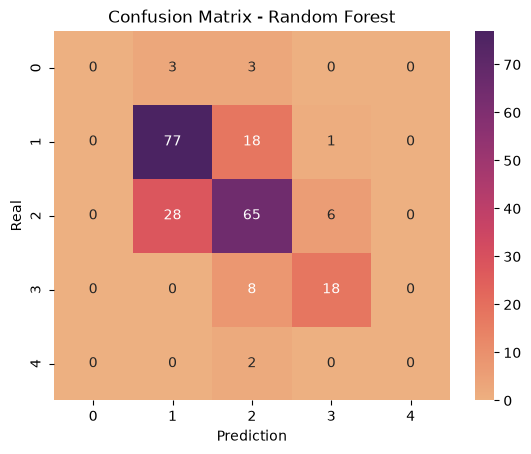

In [32]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "flare")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediction")
plt.ylabel("Real")
plt.show()

**Observation -**  

The matrix compares the model's predicted wine quality with the real wine quality.`X-axis` represents the `predicted wine quality` classes, where as, `Y-axis` represents the `real wine quality classes` from the test dataset.  
The diagonal values represent correct predictions made by the model, whereas, the off diagonal values represent incorrect predictions.  
The model correctly predicts many samples for the major quality classes, especially the middle quality wines, though the model sometimes confuses similar quality classes.

In [33]:
comparison = pd.DataFrame({"Model":["SGD","SVC","Random Forest"],"Accuracy":[sgd_accuracy, svc_accuracy, accuracy]})
comparison

,Model,Accuracy
0,SGD,0.502183
1,SVC,0.637555
2,Random Forest,0.698690


**Observation -**  

Since `Random Forest Classifier` achieved the highest accuracy of `69%`, therefore, it was selected as the final model as it provided the most accurate and reliable predictions among the three models.

**Observation -**  



In [34]:
wine = [[7.5, 0.35, 0.45, 2.5, 0.065, 25, 100, 0.996, 3.35, 0.65, 11.5]]

wine = scaler.transform(wine)
prediction = rf_model.predict(wine)
print(prediction[0])

6


C:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Key Insights -**  

1. Most wine samples have quality ratings of 5 and 6.  
2. Wines with higher alcohol content generally tend to have better quality.  
3. Higher volatile acidity is often associated with lower quality wine.  
4. The dataset is imbalanced, as quality ratings 3, 4 and 8 have very few samples.  
5. Random Forest Model achieved the highest accuracy(69%), followed by SVC(63%) and SGD Classifier(50%).

**Conclusion -**    

1. Wine Quality Prediction model was successfuly developed using machine learning techniques.  
2. The dataset was explored, cleaned and analyzed using descriptive statistics and visualizations.  
3. It was then divided into training and testing sets, and feature scaling was applied before training the machine learning models.  
4. Three classification models were evaluated: Random Forest Classifier, SGD Classifier and Support Vector Classifier.  
5. The performance of all models were compared using accuracy score, classification report and confusion matrix.  
6. Amongst the three, the one with the highest accuracy was selected as the best model for predicting wine quality.